In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, roc_auc_score)
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('data_banjir_engineered.csv')

print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"\nTarget Distribution:")
print(df['banjir'].value_counts())
print(f"\nClass Balance:")
print(df['banjir'].value_counts(normalize=True) * 100)
print(f"\nColumns: {list(df.columns)}")

Dataset Info:
Shape: (18040, 22)

Target Distribution:
banjir
0    10135
1     7905
Name: count, dtype: int64

Class Balance:
banjir
0    56.18071
1    43.81929
Name: proportion, dtype: float64

Columns: ['kabupaten_kota', 'kecamatan', 'avg_rainfall', 'max_rainfall', 'avg_temperature', 'elevation', 'landcover_class', 'ndvi', 'slope', 'soil_moisture', 'year', 'month', 'banjir', 'lat', 'long', 'jumlah_penduduk', 'rainfall_intensity', 'is_rainy_season', 'elevation_slope_ratio', 'vegetation_moisture', 'population_density_proxy', 'extreme_rainfall']


## 2. Data Preparation

Select features untuk modeling

In [3]:
# Encode landcover_class (categorical feature)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['landcover_encoded'] = le.fit_transform(df['landcover_class'])

print(f"Landcover classes encoded:")
for i, label in enumerate(le.classes_):
    print(f"  {label}: {i}")

# Select features
numerical_features = ['avg_rainfall', 'max_rainfall', 'avg_temperature', 
                      'elevation', 'ndvi', 'slope', 'soil_moisture', 'jumlah_penduduk',
                      'rainfall_intensity', 'elevation_slope_ratio', 
                      'vegetation_moisture', 'population_density_proxy']

categorical_features = ['landcover_encoded', 'month', 'is_rainy_season', 'extreme_rainfall']

feature_cols = numerical_features + categorical_features

X = df[feature_cols]
y = df['banjir']

print(f"\nFeatures selected: {len(feature_cols)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature list:")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {feat}")

Landcover classes encoded:
  Built-Up: 0
  Built-up: 1
  Cropland: 2
  Grassland: 3
  Herbaceous Wetland: 4
  Mangroves: 5
  Permanent Water Bodies: 6
  Permanent water bodies: 7
  Tree Cover: 8
  Tree cover: 9
  Unknown: 10

Features selected: 16
X shape: (18040, 16)
y shape: (18040,)

Feature list:
   1. avg_rainfall
   2. max_rainfall
   3. avg_temperature
   4. elevation
   5. ndvi
   6. slope
   7. soil_moisture
   8. jumlah_penduduk
   9. rainfall_intensity
  10. elevation_slope_ratio
  11. vegetation_moisture
  12. population_density_proxy
  13. landcover_encoded
  14. month
  15. is_rainy_season
  16. extreme_rainfall


## 3. Check for Missing Values

In [4]:
print("Missing values in features:")
print(X.isnull().sum())
print(f"\nTotal missing: {X.isnull().sum().sum()}")

if X.isnull().sum().sum() > 0:
    print("\n⚠️ Warning: Missing values detected! Filling with median...")
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col].fillna(X[col].median(), inplace=True)
    print("✅ Missing values handled")

Missing values in features:
avg_rainfall                0
max_rainfall                0
avg_temperature             0
elevation                   0
ndvi                        0
slope                       0
soil_moisture               0
jumlah_penduduk             0
rainfall_intensity          0
elevation_slope_ratio       0
vegetation_moisture         0
population_density_proxy    0
landcover_encoded           0
month                       0
is_rainy_season             0
extreme_rainfall            0
dtype: int64

Total missing: 0


## 4. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-Test Split:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTrain class balance:")
print(y_train.value_counts(normalize=True) * 100)

print(f"\nTest class distribution:")
print(y_test.value_counts())
print(f"\nTest class balance:")
print(y_test.value_counts(normalize=True) * 100)

Train-Test Split:
X_train: (14432, 16)
X_test: (3608, 16)
y_train: (14432,)
y_test: (3608,)

Train class distribution:
banjir
0    8108
1    6324
Name: count, dtype: int64

Train class balance:
banjir
0    56.18071
1    43.81929
Name: proportion, dtype: float64

Test class distribution:
banjir
0    2027
1    1581
Name: count, dtype: int64

Test class balance:
banjir
0    56.18071
1    43.81929
Name: proportion, dtype: float64


## 5. Train Random Forest (Baseline)

Train dengan parameter default + class_weight balanced untuk handling class imbalance

In [6]:
# Train baseline Random Forest
rf_baseline = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred_train = rf_baseline.predict(X_train)
y_pred_test = rf_baseline.predict(X_test)

print("Baseline Random Forest Performance:")
print("=" * 60)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"\nNumber of Trees: {rf_baseline.n_estimators}")
print(f"Max Depth: {rf_baseline.max_depth}")
print(f"Min Samples Split: {rf_baseline.min_samples_split}")
print(f"Min Samples Leaf: {rf_baseline.min_samples_leaf}")

Baseline Random Forest Performance:
Train Accuracy: 1.0000
Test Accuracy: 0.9587

Number of Trees: 100
Max Depth: None
Min Samples Split: 2
Min Samples Leaf: 1


## 6. Evaluate Model

Confusion matrix, classification report, dan metrics

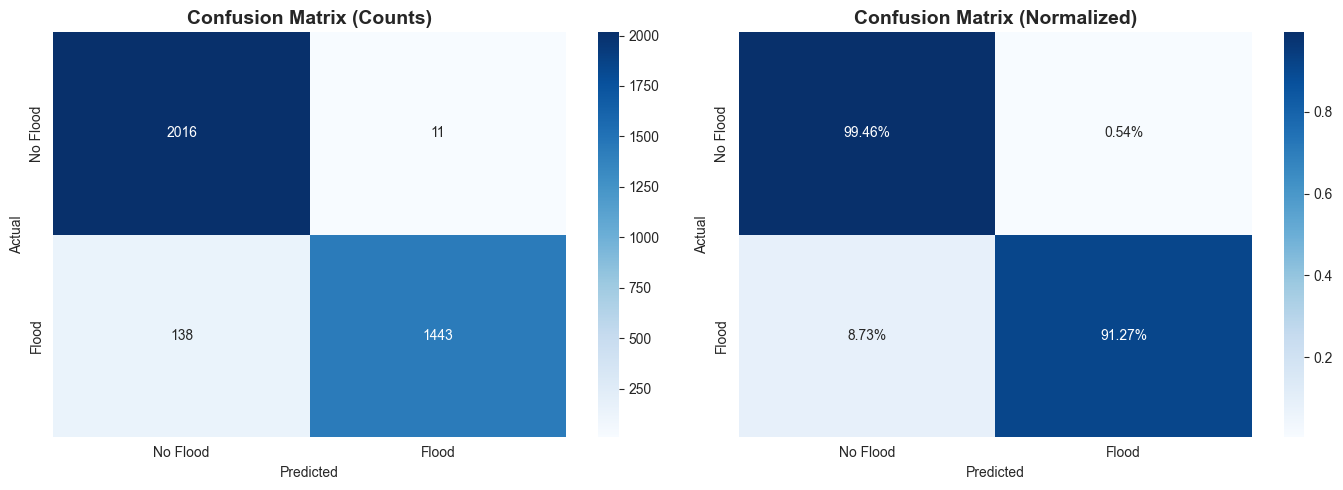


Classification Report:
              precision    recall  f1-score   support

    No Flood       0.94      0.99      0.96      2027
       Flood       0.99      0.91      0.95      1581

    accuracy                           0.96      3608
   macro avg       0.96      0.95      0.96      3608
weighted avg       0.96      0.96      0.96      3608



In [7]:
cm = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (counts)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Flood', 'Flood'], 
            yticklabels=['No Flood', 'Flood'])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix (normalized)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['No Flood', 'Flood'], 
            yticklabels=['No Flood', 'Flood'])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_test, target_names=['No Flood', 'Flood']))

Detailed Metrics:
Accuracy:  0.9587
Precision: 0.9924
Recall:    0.9127
F1-Score:  0.9509


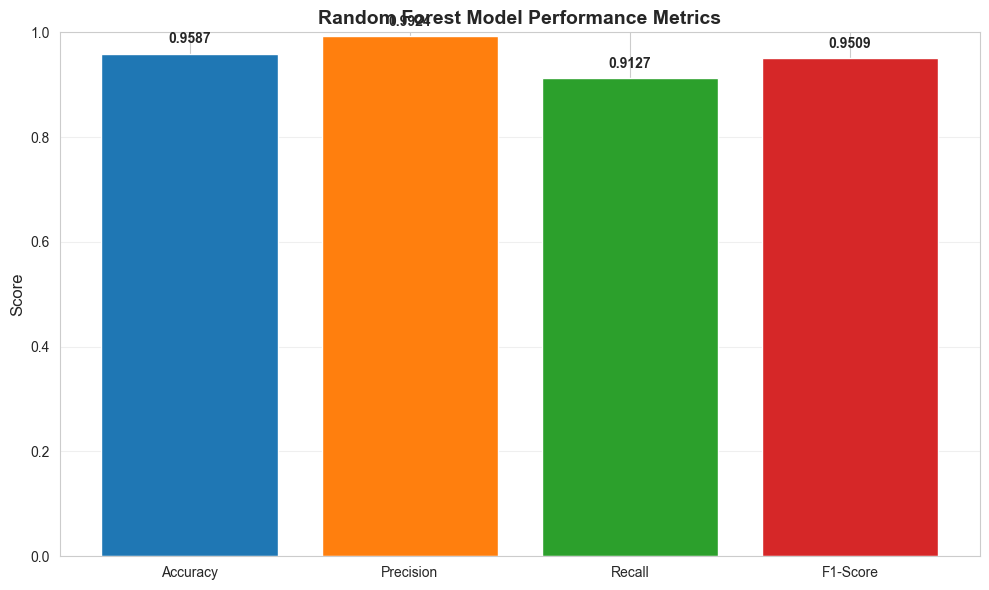

In [8]:
# Detailed metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print("Detailed Metrics:")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Metrics visualization
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}
plt.figure(figsize=(10, 6))
plt.bar(metrics.keys(), metrics.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylim(0, 1.0)
plt.ylabel('Score', fontsize=12)
plt.title('Random Forest Model Performance Metrics', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(metrics.items()):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. ROC Curve dan AUC

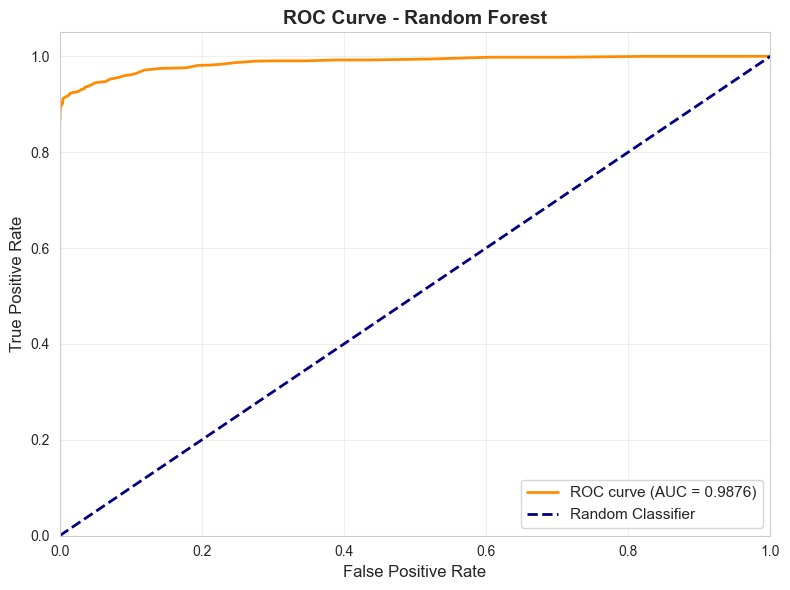

ROC-AUC Score: 0.9876


In [9]:
# Predict probabilities
y_pred_proba = rf_baseline.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 8. Feature Importance

Analisis fitur mana yang paling penting dalam prediksi

Feature Importance:
landcover_encoded             : 0.2626
jumlah_penduduk               : 0.2126
avg_temperature               : 0.1052
population_density_proxy      : 0.0794
slope                         : 0.0541
avg_rainfall                  : 0.0466
soil_moisture                 : 0.0376
max_rainfall                  : 0.0355
elevation_slope_ratio         : 0.0317
ndvi                          : 0.0280
elevation                     : 0.0274
vegetation_moisture           : 0.0260
rainfall_intensity            : 0.0239
month                         : 0.0187
extreme_rainfall              : 0.0058
is_rainy_season               : 0.0050


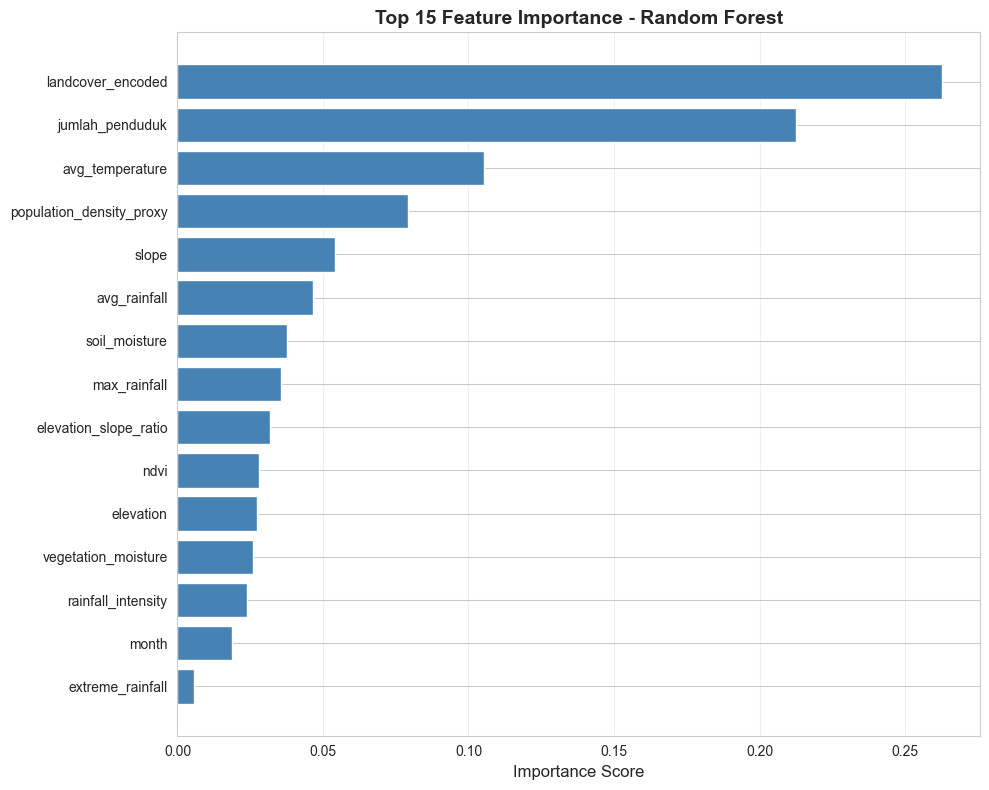

In [10]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_baseline.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print("=" * 60)
for i, row in feature_importance.iterrows():
    print(f"{row['feature']:30s}: {row['importance']:.4f}")

# Plot feature importance (top 15)
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Cross-Validation

Validasi performa model dengan cross-validation

Cross-Validation Results (5-Fold):
Fold Scores: [0.9594735  0.95219952 0.95530146 0.95772696 0.95426195]
Mean Accuracy: 0.9558
Std Deviation: 0.0026
95% Confidence Interval: [0.9508, 0.9608]


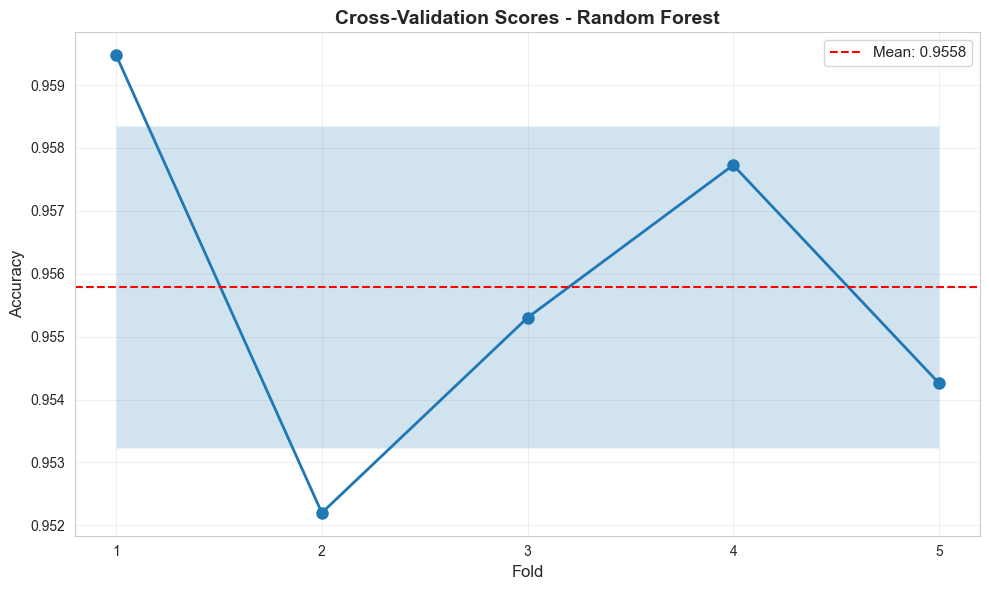

In [11]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Results (5-Fold):")
print("=" * 60)
print(f"Fold Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), 
                 cv_scores.mean() + cv_scores.std(), alpha=0.2)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Validation Scores - Random Forest', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning dengan GridSearchCV

Mencari kombinasi parameter terbaik untuk meningkatkan performa

In [12]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("GridSearchCV Parameter Grid:")
print("=" * 60)
for param, values in param_grid.items():
    print(f"{param:20s}: {values}")

print(f"\nTotal combinations: {np.prod([len(v) for v in param_grid.values()])}")
print(f"This may take several minutes...\n")

# Perform GridSearchCV
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nGridSearchCV Results:")
print("=" * 60)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

GridSearchCV Parameter Grid:
n_estimators        : [100, 200, 300]
max_depth           : [10, 20, 30, None]
min_samples_split   : [2, 5, 10]
min_samples_leaf    : [1, 2, 4]
max_features        : ['sqrt', 'log2']

Total combinations: 216
This may take several minutes...

Fitting 3 folds for each of 216 candidates, totalling 648 fits

GridSearchCV Results:
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (F1): 0.9486


## 10.1. Confusion Matrix - Tuned Model

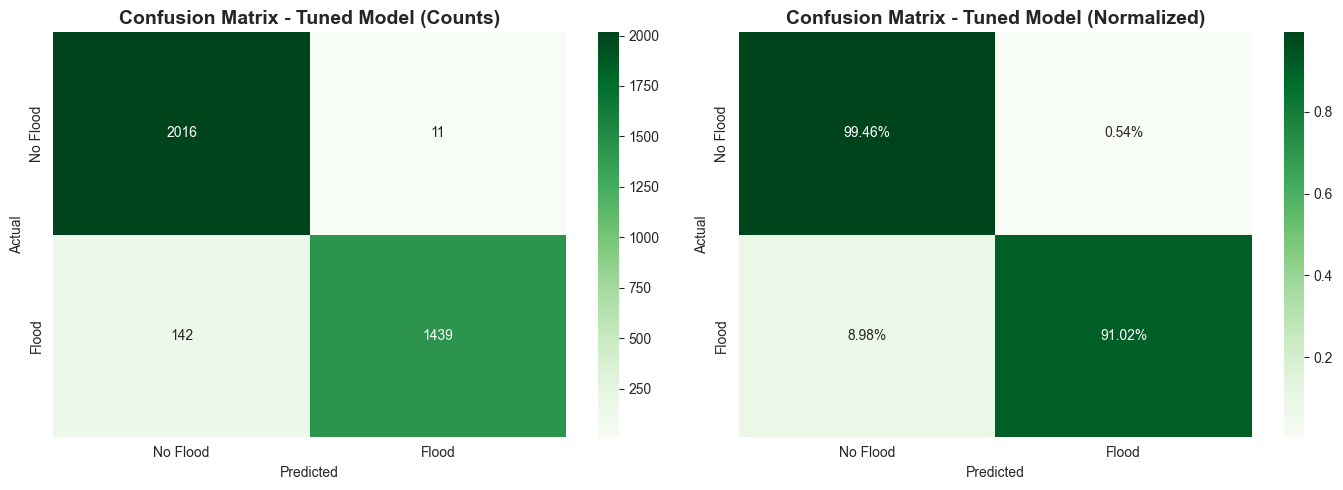


Classification Report - Tuned Model:
              precision    recall  f1-score   support

    No Flood       0.93      0.99      0.96      2027
       Flood       0.99      0.91      0.95      1581

    accuracy                           0.96      3608
   macro avg       0.96      0.95      0.96      3608
weighted avg       0.96      0.96      0.96      3608



In [13]:
# Get best model and make predictions
rf_tuned = grid_search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)

# Confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (counts)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Flood', 'Flood'], 
            yticklabels=['No Flood', 'Flood'])
axes[0].set_title('Confusion Matrix - Tuned Model (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix (normalized)
cm_norm_tuned = cm_tuned.astype('float') / cm_tuned.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm_tuned, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['No Flood', 'Flood'], 
            yticklabels=['No Flood', 'Flood'])
axes[1].set_title('Confusion Matrix - Tuned Model (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print("\nClassification Report - Tuned Model:")
print("=" * 60)
print(classification_report(y_test, y_pred_tuned, target_names=['No Flood', 'Flood']))

## 10.2. ROC Curve - Tuned Model

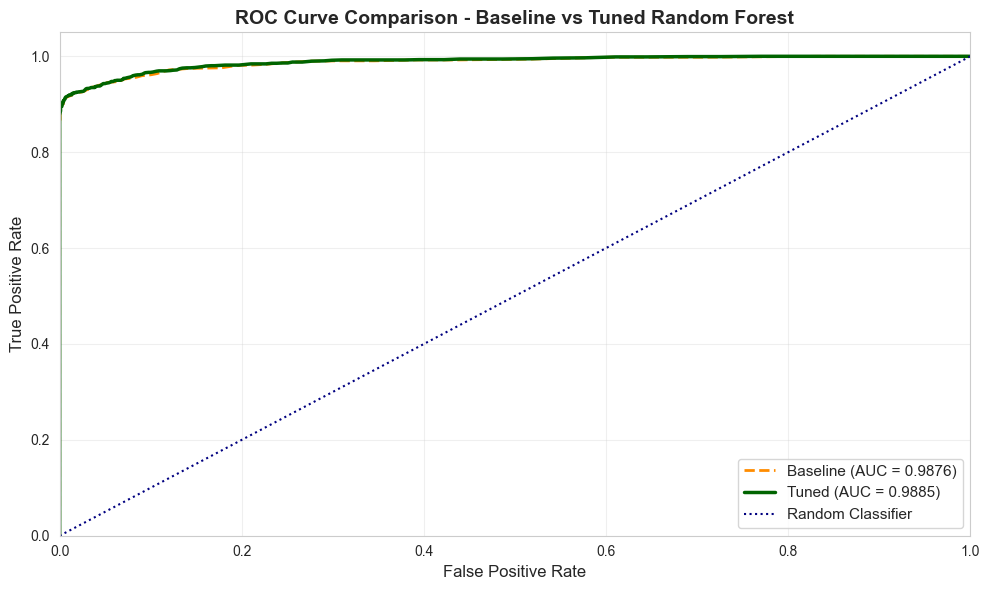

ROC-AUC Score - Baseline: 0.9876
ROC-AUC Score - Tuned:    0.9885
Improvement:              +0.09%


In [14]:
# Predict probabilities for tuned model
y_pred_proba_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_test, y_pred_proba_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

# Plot ROC curve - comparison
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Baseline (AUC = {roc_auc:.4f})', linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, color='darkgreen', lw=2.5, label=f'Tuned (AUC = {roc_auc_tuned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle=':', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Baseline vs Tuned Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score - Baseline: {roc_auc:.4f}")
print(f"ROC-AUC Score - Tuned:    {roc_auc_tuned:.4f}")
print(f"Improvement:              {((roc_auc_tuned - roc_auc) / roc_auc * 100):+.2f}%")

## 11. Evaluate Tuned Model

In [15]:
# Best model from GridSearch
rf_tuned = grid_search.best_estimator_

# Predictions
y_pred_train_tuned = rf_tuned.predict(X_train)
y_pred_test_tuned = rf_tuned.predict(X_test)

print("Tuned Random Forest Performance:")
print("=" * 60)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train_tuned):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_tuned):.4f}")

print("\nClassification Report (Tuned):")
print("=" * 60)
print(classification_report(y_test, y_pred_test_tuned, target_names=['No Flood', 'Flood']))

# Compare metrics
print("\nComparison: Baseline vs Tuned")
print("=" * 60)
print(f"{'Metric':<15s} {'Baseline':<12s} {'Tuned':<12s} {'Improvement'}")
print("-" * 60)

metrics_baseline = {
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'Recall': recall_score(y_test, y_pred_test),
    'F1-Score': f1_score(y_test, y_pred_test)
}

metrics_tuned = {
    'Accuracy': accuracy_score(y_test, y_pred_test_tuned),
    'Precision': precision_score(y_test, y_pred_test_tuned),
    'Recall': recall_score(y_test, y_pred_test_tuned),
    'F1-Score': f1_score(y_test, y_pred_test_tuned)
}

for metric in metrics_baseline.keys():
    baseline_val = metrics_baseline[metric]
    tuned_val = metrics_tuned[metric]
    improvement = ((tuned_val - baseline_val) / baseline_val) * 100
    print(f"{metric:<15s} {baseline_val:>10.4f}   {tuned_val:>10.4f}   {improvement:>+6.2f}%")

Tuned Random Forest Performance:
Train Accuracy: 1.0000
Test Accuracy: 0.9576

Classification Report (Tuned):
              precision    recall  f1-score   support

    No Flood       0.93      0.99      0.96      2027
       Flood       0.99      0.91      0.95      1581

    accuracy                           0.96      3608
   macro avg       0.96      0.95      0.96      3608
weighted avg       0.96      0.96      0.96      3608


Comparison: Baseline vs Tuned
Metric          Baseline     Tuned        Improvement
------------------------------------------------------------
Accuracy            0.9587       0.9576    -0.12%
Precision           0.9924       0.9924    -0.00%
Recall              0.9127       0.9102    -0.28%
F1-Score            0.9509       0.9495    -0.15%


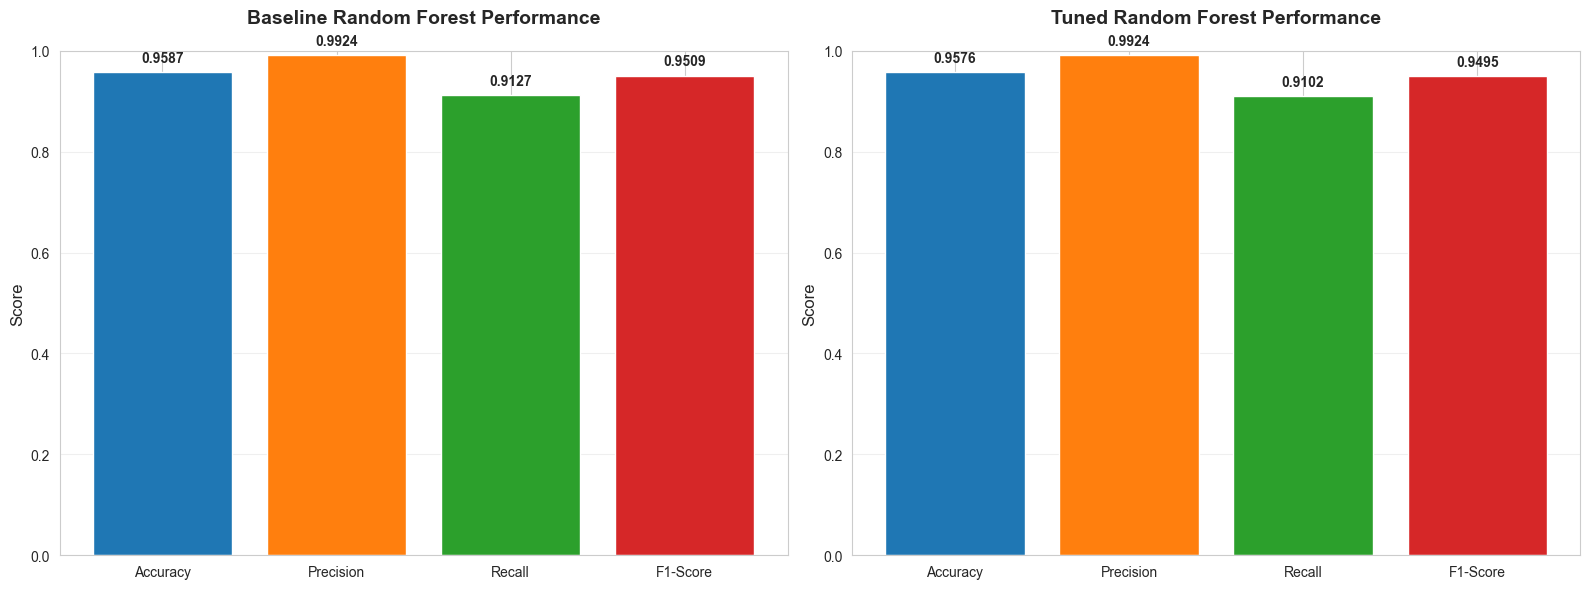

In [19]:
# Side-by-side comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline metrics
axes[0].bar(metrics_baseline.keys(), metrics_baseline.values(), 
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Baseline Random Forest Performance', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(metrics_baseline.items()):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Tuned metrics
axes[1].bar(metrics_tuned.keys(), metrics_tuned.values(), 
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Tuned Random Forest Performance', fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(metrics_tuned.items()):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Final Model Summary

In [17]:
print("=" * 70)
print("RANDOM FOREST MODEL SUMMARY")
print("=" * 70)

print("\n📊 Dataset:")
print(f"   Total samples: {len(df):,}")
print(f"   Features: {len(feature_cols)}")
print(f"   Train size: {len(X_train):,}")
print(f"   Test size: {len(X_test):,}")

print("\n🎯 Best Model Configuration:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"   class_weight: balanced")

print("\n📈 Performance Metrics (Test Set):")
for metric, value in metrics_tuned.items():
    print(f"   {metric}: {value:.4f}")

# ROC-AUC for tuned model
y_pred_proba_tuned = rf_tuned.predict_proba(X_test)[:, 1]
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)
print(f"   ROC-AUC: {roc_auc_tuned:.4f}")

print("\n🔝 Top 5 Important Features:")
feature_importance_tuned = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_tuned.feature_importances_
}).sort_values('importance', ascending=False)

for i, row in feature_importance_tuned.head(5).iterrows():
    print(f"   {row['feature']:30s}: {row['importance']:.4f}")

print("\n" + "=" * 70)
print("✅ Random Forest modeling completed successfully!")
print("=" * 70)

RANDOM FOREST MODEL SUMMARY

📊 Dataset:
   Total samples: 18,040
   Features: 16
   Train size: 14,432
   Test size: 3,608

🎯 Best Model Configuration:
   max_depth: None
   max_features: sqrt
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 300
   class_weight: balanced

📈 Performance Metrics (Test Set):
   Accuracy: 0.9576
   Precision: 0.9924
   Recall: 0.9102
   F1-Score: 0.9495
   ROC-AUC: 0.9885

🔝 Top 5 Important Features:
   landcover_encoded             : 0.2691
   jumlah_penduduk               : 0.2093
   avg_temperature               : 0.1007
   population_density_proxy      : 0.0759
   slope                         : 0.0528

✅ Random Forest modeling completed successfully!


## 13. Save Model (Optional)

In [18]:
import pickle

# Save the tuned model
with open('random_forest_tuned_model.pkl', 'wb') as f:
    pickle.dump(rf_tuned, f)

print("✅ Model saved: random_forest_tuned_model.pkl")

# Save feature names
with open('feature_names_rf.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("✅ Feature names saved: feature_names_rf.pkl")

✅ Model saved: random_forest_tuned_model.pkl
✅ Feature names saved: feature_names_rf.pkl
